# Logistic Regression Experiments
This notebook is a lightweight sandbox for primitive test runs.

Run cells in order from top to bottom.

In [22]:
import os
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from preprocessing import build_raw_dataset

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Data root in this repo
BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"
TWEETS_FILE = "tweets.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "reply_count", "favorite_count", "num_urls", "num_mentions"
]

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9


In [23]:
# Block 1: Data loading (full configured datasets)
raw = build_raw_dataset(DATASETS, BASE_DIR, TWEET_FEATURES)

raw.shape

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368


(14368, 48)

In [24]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X = pd.concat([X, raw[tweet_features]], axis=1)

X = X.fillna(0)

print(X.columns) 
print(X.shape)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))

Index(['statuses_count', 'followers_count', 'friends_count',
       'favourites_count', 'listed_count', 'default_profile',
       'default_profile_image', 'verified', 'reply_count', 'favorite_count',
       'num_urls', 'num_mentions'],
      dtype='str')
(14368, 12)
Train shape: (11494, 12)
Test shape: (2874, 12)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64


In [25]:
# Block 3: Training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

print("Training complete.")
print("Model intercept:", model.intercept_[0])

Training complete.
Model intercept: 7.907489487795258


In [26]:
# Block 4: Evaluation
pred = model.predict(X_test_scaled)

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 features by |coefficient|:")
display(coef_df.head(10))

accuracy:          0.9548
balanced_accuracy: 0.9305
f1_macro:          0.9373
roc_auc:           0.9305
AUPRC:             0.9588

Confusion Matrix:
[[ 614   81]
 [  49 2130]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9261    0.8835    0.9043       695
           1     0.9634    0.9775    0.9704      2179

    accuracy                         0.9548      2874
   macro avg     0.9447    0.9305    0.9373      2874
weighted avg     0.9544    0.9548    0.9544      2874


Top 10 features by |coefficient|:


,feature,coefficient,abs_coefficient
3,favourites_count,-14.828599,14.828599
10,num_urls,11.636506,11.636506
11,num_mentions,10.771476,10.771476
8,reply_count,2.443423,2.443423
0,statuses_count,-1.050603,1.050603
1,followers_count,0.398634,0.398634
9,favorite_count,0.368258,0.368258
7,verified,-0.332593,0.332593
5,default_profile,0.179046,0.179046
6,default_profile_image,-0.105469,0.105469


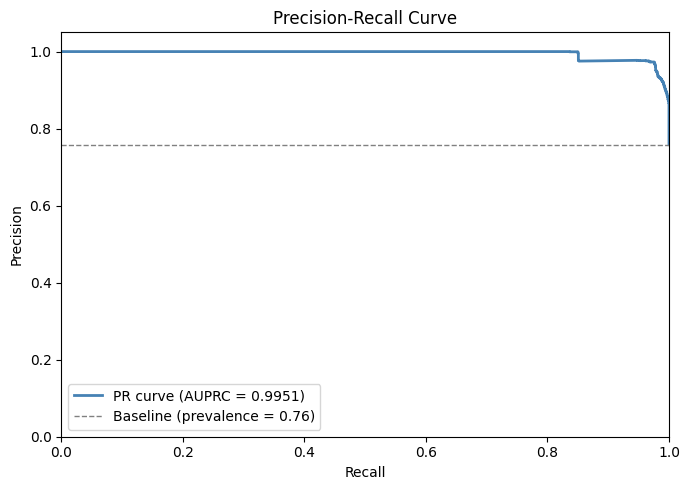

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
auprc = average_precision_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUPRC = {auprc:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Run Order
1. Cell 2: imports and constants.
2. Cell 3: full data loading.
3. Cell 4: slicing and preprocessing.
4. Cell 5: training.
5. Cell 6: evaluation.

## Notes
- This notebook now loads all configured dataset files directly.
- If runtime or memory gets heavy, reduce loaded columns or process in chunks.